# Comment Matching Analysis

This notebook analyzes comment-level alignment, the judges' diagnostic flags, qualitative examples, and guideline references in one top-to-bottom workflow.


In [1]:
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from scipy.optimize import linear_sum_assignment


ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils" / "paths.py").exists())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
from utils.paths import HUMAN_REFERENCE_DIR, RESULTS_DIR as ALL_RESULTS_DIR

NOTEBOOK_DIR = ROOT / "notebooks" / "3_analysis"
RESULTS_DIR = ALL_RESULTS_DIR / "critiques" / "analysis"
MATCHING_DIR = ALL_RESULTS_DIR / "critiques" / "matching"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
QUALITATIVE_DIR = TABLES_DIR / "qualitative_examples"
for directory in [TABLES_DIR, FIGURES_DIR, QUALITATIVE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

from utils.comments.guidelines import (
    APPLE_SUBCATEGORY_PARENT,
    APPLE_TOP_LOOKUP,
    CANONICAL_SOURCES,
    NIELSEN_CATEGORIES,
    NIELSEN_LOOKUP,
    build_parsed_long_df,
    clean_text,
    normalize_key,
    parse_guideline_references,
)
from utils.comments.judge import DIAGNOSTIC_COLUMNS, RELATION_DIAGNOSTICS
from utils.screen_display import show_screen

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

RUN_LABEL = "zero_shot-all_tasks"
MODEL_ORDER = ["claude4_7", "gpt5", "gemini3_1pro"]
MODEL_DISPLAY = {
    "claude4_7": "Claude Opus 4.7",
    "gpt5": "GPT-5",
    "gemini3_1pro": "Gemini 3.1 Pro",
}
MODEL_COLORS = {
    "claude4_7": "#F89838",
    "gpt5": "#5288C1",
    "gemini3_1pro": "#73C068",
}
MODEL_RANK = {model: rank for rank, model in enumerate(MODEL_ORDER)}

K_VALUES = [1, 3, 5]
BOOTSTRAP_ITERATIONS = 1000
RANDOM_SEED = 42

PAIR_KEYS = ["model_short", "screen_task_id", "expert_comment_id", "llm_comment_id"]
MODEL_GROUP_COLS = ["model_short", "model_name"]
EXPERT_GROUP_COLS = [*MODEL_GROUP_COLS, "screen_task_id", "expert_comment_id"]
LLM_GROUP_COLS = [*MODEL_GROUP_COLS, "screen_task_id", "llm_comment_id"]
SCREEN_GROUP_COLS = [*MODEL_GROUP_COLS, "app_name", "app_category", "screen_task_id"]

# Relation labels are canonicalized on load: the judge's B_broader / A_broader become
# llm_broader / human_broader. RELATION_ORDER doubles as the ranking order, best match first.
RELATION_ORDER = [
    "equivalent",
    "llm_broader",
    "human_broader",
    "partial_overlap",
    "contradiction",
    "related_but_different",
    "no_match",
]
RELATION_RANK = {relation: rank for rank, relation in enumerate(RELATION_ORDER)}
RELATION_ALIASES = {
    "equivalent": "equivalent",
    "B_broader": "llm_broader",
    "A_broader": "human_broader",
    "partial_overlap": "partial_overlap",
    "contradiction": "contradiction",
    "related_but_different": "related_but_different",
    "no_match": "no_match",
}
RELATION_WEIGHTS = {
    "equivalent": 1.00,
    "llm_broader": 0.85,
    "human_broader": 0.85,
    "partial_overlap": 0.50,
    "contradiction": 0.00,
    "related_but_different": 0.00,
    "no_match": 0.00,
}


def canonical_relation(values: pd.Series) -> pd.Series:
    """Map the judge's relation labels onto RELATION_ORDER."""
    unknown = sorted(set(values.dropna().unique()) - set(RELATION_ALIASES))
    if unknown:
        raise ValueError(f"Unrecognized relation labels: {unknown}")
    return values.map(RELATION_ALIASES)


def display_df(df: pd.DataFrame) -> None:
    display(df.drop(columns=["model_short"], errors="ignore"))


def model_color(display_name: str) -> str:
    return MODEL_COLORS[next(model for model in MODEL_ORDER if MODEL_DISPLAY[model] == display_name)]


def save_figure(filename: str, fig=None) -> None:
    (fig or plt.gcf()).savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Load and Prepare Matching Data


In [2]:
ARTIFACTS = {
    "all_pairs": "all_comment_pairs-{stem}.parquet",
    "pair_labels": "llmjudge_matching/llmjudge_matching_pairs-{stem}.parquet",
}

# GPT-5 returned an empty critique list for these two tasks, so they have no candidate
# pairs and are dropped from every model to keep the comparison on a shared task set.
EXCLUDED_SCREEN_TASK_IDS = {"20234_T03", "31563_T02"}


def load_artifact(model: str, artifact: str) -> pd.DataFrame:
    stem = f"{RUN_LABEL}-{model}"
    path = MATCHING_DIR / model / RUN_LABEL / ARTIFACTS[artifact].format(stem=stem)
    df = pd.read_parquet(path)
    df["model_short"] = model
    df["model_name"] = MODEL_DISPLAY[model]
    return df


def load_all(artifact: str) -> pd.DataFrame:
    df = pd.concat([load_artifact(model, artifact) for model in MODEL_ORDER], ignore_index=True)
    return df[~df["screen_task_id"].isin(EXCLUDED_SCREEN_TASK_IDS)].reset_index(drop=True)


all_pairs_df = load_all("all_pairs")
pair_labels_df = load_all("pair_labels")
pair_labels_df["relation"] = canonical_relation(pair_labels_df["relation"])
# Each judge's own answers are stored as `<field>__<judge>` columns (relations keep the judge's raw labels).
JUDGES = sorted({col.split("__")[1] for col in pair_labels_df if col.startswith("relation__")})

human_tasks = (
    pd.read_parquet(HUMAN_REFERENCE_DIR / "human_comments_semantic_dedup.parquet")
    [["screen_task_id", "app", "app_category"]]
    .rename(columns={"app": "app_name"})
    .drop_duplicates("screen_task_id")
)

# `pairs` is the weighted pair table used by the cardinality-controlled metrics.
pairs = pair_labels_df.merge(human_tasks, on="screen_task_id", how="left")
pairs["relation_weight"] = pairs["relation"].map(RELATION_WEIGHTS).astype(float)

# Preserve the original generated-comment order through first appearance in the pair table.
llm_order = (
    pairs[["model_short", "screen_task_id", "llm_comment_id"]]
    .drop_duplicates()
    .assign(llm_position=lambda x: x.groupby(["model_short", "screen_task_id"]).cumcount() + 1)
)
pairs = pairs.merge(llm_order, on=["model_short", "screen_task_id", "llm_comment_id"], how="left")

load_summary = (
    pairs.groupby(MODEL_GROUP_COLS, sort=False)
    .agg(
        pair_rows=("pair_id", "size"),
        screen_tasks=("screen_task_id", "nunique"),
        expert_comments=("expert_comment_id", "nunique"),
        llm_comments=("llm_comment_id", "nunique"),
        apps=("app_name", "nunique"),
    )
    .reset_index()
)
load_summary

,model_short,model_name,pair_rows,screen_tasks,expert_comments,llm_comments,apps
0,claude4_7,Claude Opus 4.7,72258,2950,10488,20149,871
1,gpt5,GPT-5,64255,2950,10488,17892,871
2,gemini3_1pro,Gemini 3.1 Pro,36007,2950,10488,9978,871


### 1.1 Prepare Pair-Level Metrics and Expert-Coverage Selections

Enrich selected relation rows with automatic metrics and derive one best match per expert comment for the qualitative analyses.


In [3]:
# `metric_pairs_df` is the pair table with expert/LLM text and screen context attached;
# the qualitative sections read their examples from it.
pair_context_columns = [col for col in all_pairs_df.columns if col not in {"pair_id", "model_name"}]
metric_pairs_df = (
    pair_labels_df[[*PAIR_KEYS, "model_name", "pair_id", "relation", "confidence", *DIAGNOSTIC_COLUMNS]].drop_duplicates(PAIR_KEYS)
    .merge(
        all_pairs_df[pair_context_columns].drop_duplicates(PAIR_KEYS),
        on=PAIR_KEYS,
        how="left",
        validate="one_to_one",
    )
)


def best_ranked_relation(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """Keep the single best-ranked (then highest-confidence) row per group."""
    ranked = df.assign(relation_rank=df["relation"].map(RELATION_RANK))
    ranked = ranked[ranked["relation_rank"].notna()]
    return (
        ranked.sort_values(
            [*group_cols, "relation_rank", "confidence"],
            ascending=[True] * len(group_cols) + [True, False],
        )
        .drop_duplicates(group_cols)
        .drop(columns="relation_rank")
    )


# One selected match per expert comment; drives the qualitative coverage analyses.
expert_coverage_df = (
    all_pairs_df[EXPERT_GROUP_COLS].drop_duplicates()
    .merge(
        best_ranked_relation(pair_labels_df, EXPERT_GROUP_COLS)[
            [*EXPERT_GROUP_COLS, "llm_comment_id", "relation", "confidence"]
        ].rename(columns={"relation": "best_relation", "confidence": "best_confidence"}),
        on=EXPERT_GROUP_COLS,
        how="left",
    )
)
display_df(expert_coverage_df.head(3))

,model_name,screen_task_id,expert_comment_id,llm_comment_id,best_relation,best_confidence
0,Claude Opus 4.7,10089_T01,10089_T01_002,L_claude4_7_10089_T01_001,no_match,0.975
1,Claude Opus 4.7,10089_T01,10089_T01_003,L_claude4_7_10089_T01_002,llm_broader,0.730
2,Claude Opus 4.7,10089_T01,10089_T01_004,L_claude4_7_10089_T01_006,related_but_different,0.810


### 1.2 Input Validation

A single pass over the loaded tables. Structural problems (missing columns, unaligned
models, duplicate keys) raise; unexpected nulls are reported as warnings so that they
surface early instead of showing up as silent gaps in a downstream table.


In [4]:
def validate_inputs() -> None:
    """Raise on structural problems; warn on anything merely surprising."""
    required = {"pair_id", *PAIR_KEYS, "relation", "confidence", "expert_observed_issue", "llm_observed_issue", *DIAGNOSTIC_COLUMNS}
    task_sets = {m: set(all_pairs_df.loc[all_pairs_df["model_short"].eq(m), "screen_task_id"]) for m in MODEL_ORDER}

    errors = []
    if missing := sorted(required - set(pair_labels_df.columns)):
        errors.append(f"pair labels missing columns: {missing}")
    if leaked := sorted(EXCLUDED_SCREEN_TASK_IDS & set(all_pairs_df["screen_task_id"])):
        errors.append(f"excluded tasks still present: {leaked}")
    if differing := [m for m, t in task_sets.items() if t != task_sets[MODEL_ORDER[0]]]:
        errors.append(f"task set differs for: {differing}")
    if misaligned := [m for m in MODEL_ORDER
                      if all_pairs_df["model_short"].eq(m).sum() != pair_labels_df["model_short"].eq(m).sum()]:
        errors.append(f"pair/label row counts differ for: {misaligned}")
    if pair_labels_df.duplicated(["model_short", "pair_id"]).any():
        errors.append("duplicate pair_id within a model")
    if len(JUDGES) != 2:
        errors.append(f"expected two judges' answers, found: {JUDGES}")
    if unmapped := int(metric_pairs_df["relation"].isna().sum()):
        errors.append(f"{unmapped:,} pairs without a relation")
    if orphaned := int(metric_pairs_df["expert_observed_issue"].isna().sum()):
        errors.append(f"{orphaned:,} pairs without expert text")
    if "llm_guideline_reference" not in all_pairs_df.columns:
        errors.append("all_pairs is missing llm_guideline_reference")
    if errors:
        raise ValueError("Input validation failed:\n- " + "\n- ".join(errors))

    nulls = {f"{name}.{col}": int(df[col].isna().sum())
             for name, df, cols in [("labels", pair_labels_df, ["confidence", "expert_observed_issue", "llm_observed_issue"]),
                                    ("pairs", all_pairs_df, ["screen_id", "task", "app_category"]),
                                    ("pairs", pairs, ["app_name"])]
             for col in cols if df[col].isna().any()}
    if nulls:
        print("warning - unexpected nulls:", "; ".join(f"{k}={v:,}" for k, v in nulls.items()))

    print(f"Validation passed: {len(task_sets[MODEL_ORDER[0]]):,} shared screen tasks across {len(MODEL_ORDER)} models.")


validate_inputs()

Validation passed: 2,950 shared screen tasks across 3 models.


## 2. Alignment Metrics


### 2.1 Macro-Averaged Unconstrained and Bipartite Metrics


In [5]:
def _assignment_scores(weights: np.ndarray, expert_count: int, llm_count: int) -> tuple[float, float, float]:
    if expert_count == 0 or llm_count == 0:
        return np.nan, np.nan, 0.0
    row_ind, col_ind = linear_sum_assignment(-weights)
    matched_sum = float(weights[row_ind, col_ind].sum())
    return matched_sum / expert_count, matched_sum / llm_count, matched_sum


def _weighted_matrix(screen_pairs: pd.DataFrame) -> pd.DataFrame:
    llm_ordered = (
        screen_pairs[["llm_comment_id", "llm_position"]]
        .drop_duplicates()
        .sort_values("llm_position")["llm_comment_id"]
        .tolist()
    )
    return screen_pairs.pivot_table(
        index="expert_comment_id",
        columns="llm_comment_id",
        values="relation_weight",
        aggfunc="max",
        fill_value=0.0,
    ).reindex(columns=llm_ordered, fill_value=0.0)


screen_rows = []
k_screen_rows = []

for keys, screen_pairs in pairs.groupby(SCREEN_GROUP_COLS, sort=False):
    key_values = dict(zip(SCREEN_GROUP_COLS, keys))
    matrix = _weighted_matrix(screen_pairs)
    weights = matrix.to_numpy(dtype=float)
    expert_count, llm_count = matrix.shape

    bip_cov, bip_sup, matched_sum = _assignment_scores(weights, expert_count, llm_count)
    screen_rows.append({
        **key_values,
        "unconstrained_expert_coverage": float(weights.max(axis=1).mean()) if expert_count else np.nan,
        "unconstrained_reference_support": float(weights.max(axis=0).mean()) if llm_count else np.nan,
        "bipartite_expert_coverage": bip_cov,
        "bipartite_reference_support": bip_sup,
        "matched_weight_sum": matched_sum,
        "expert_comments": expert_count,
        "llm_comments": llm_count,
    })

    positions = (
        screen_pairs[["llm_comment_id", "llm_position"]]
        .drop_duplicates()
        .set_index("llm_comment_id")
        .loc[matrix.columns, "llm_position"]
        .to_numpy()
    )
    for k in K_VALUES:
        keep = positions <= k
        k_cov, k_sup, _ = _assignment_scores(weights[:, keep], expert_count, int(keep.sum()))
        k_screen_rows.append({**key_values, "k": k, "bipartite_expert_coverage": k_cov, "bipartite_reference_support": k_sup})

screen_metrics = pd.DataFrame(screen_rows)
k_screen_metrics = pd.DataFrame(k_screen_rows)

core_metric_cols = [
    "unconstrained_expert_coverage",
    "unconstrained_reference_support",
    "bipartite_expert_coverage",
    "bipartite_reference_support",
]


def as_percent(df: pd.DataFrame, metric_cols: list[str]) -> pd.DataFrame:
    """Rename metric columns to *_pct and scale them to percentages."""
    out = df.rename(columns={metric: f"{metric}_pct" for metric in metric_cols}).copy()
    out[[f"{metric}_pct" for metric in metric_cols]] *= 100
    return out.round(1)


core_metrics_pct = as_percent(
    screen_metrics.groupby(MODEL_GROUP_COLS, sort=False)[core_metric_cols].mean().reset_index(),
    core_metric_cols,
)
screen_metrics.round(2).to_parquet(TABLES_DIR / "screen_level_alignment_metrics.parquet", index=False)
core_metrics_pct

,model_short,model_name,unconstrained_expert_coverage_pct,unconstrained_reference_support_pct,bipartite_expert_coverage_pct,bipartite_reference_support_pct
0,claude4_7,Claude Opus 4.7,25.1,12.3,23.6,11.4
1,gpt5,GPT-5,23.1,12.6,21.3,11.8
2,gemini3_1pro,Gemini 3.1 Pro,20.6,19.0,18.9,18.2


#### 2.1.1 Clustered App-Level Bootstrap Confidence Intervals


,model_short,model_name,metric,point_estimate_pct,ci_low_pct,ci_high_pct,bootstrap_iterations
0,claude4_7,Claude Opus 4.7,unconstrained_expert_coverage,25.1,24.0,26.2,1000
1,claude4_7,Claude Opus 4.7,unconstrained_reference_support,12.3,11.8,12.9,1000
2,claude4_7,Claude Opus 4.7,bipartite_expert_coverage,23.6,22.5,24.7,1000
3,claude4_7,Claude Opus 4.7,bipartite_reference_support,11.4,10.9,11.9,1000
4,gpt5,GPT-5,unconstrained_expert_coverage,23.1,22.0,24.2,1000
5,gpt5,GPT-5,unconstrained_reference_support,12.6,12.0,13.2,1000
6,gpt5,GPT-5,bipartite_expert_coverage,21.3,20.3,22.3,1000
7,gpt5,GPT-5,bipartite_reference_support,11.8,11.3,12.3,1000
8,gemini3_1pro,Gemini 3.1 Pro,unconstrained_expert_coverage,20.6,19.6,21.6,1000
9,gemini3_1pro,Gemini 3.1 Pro,unconstrained_reference_support,19.0,18.1,19.8,1000


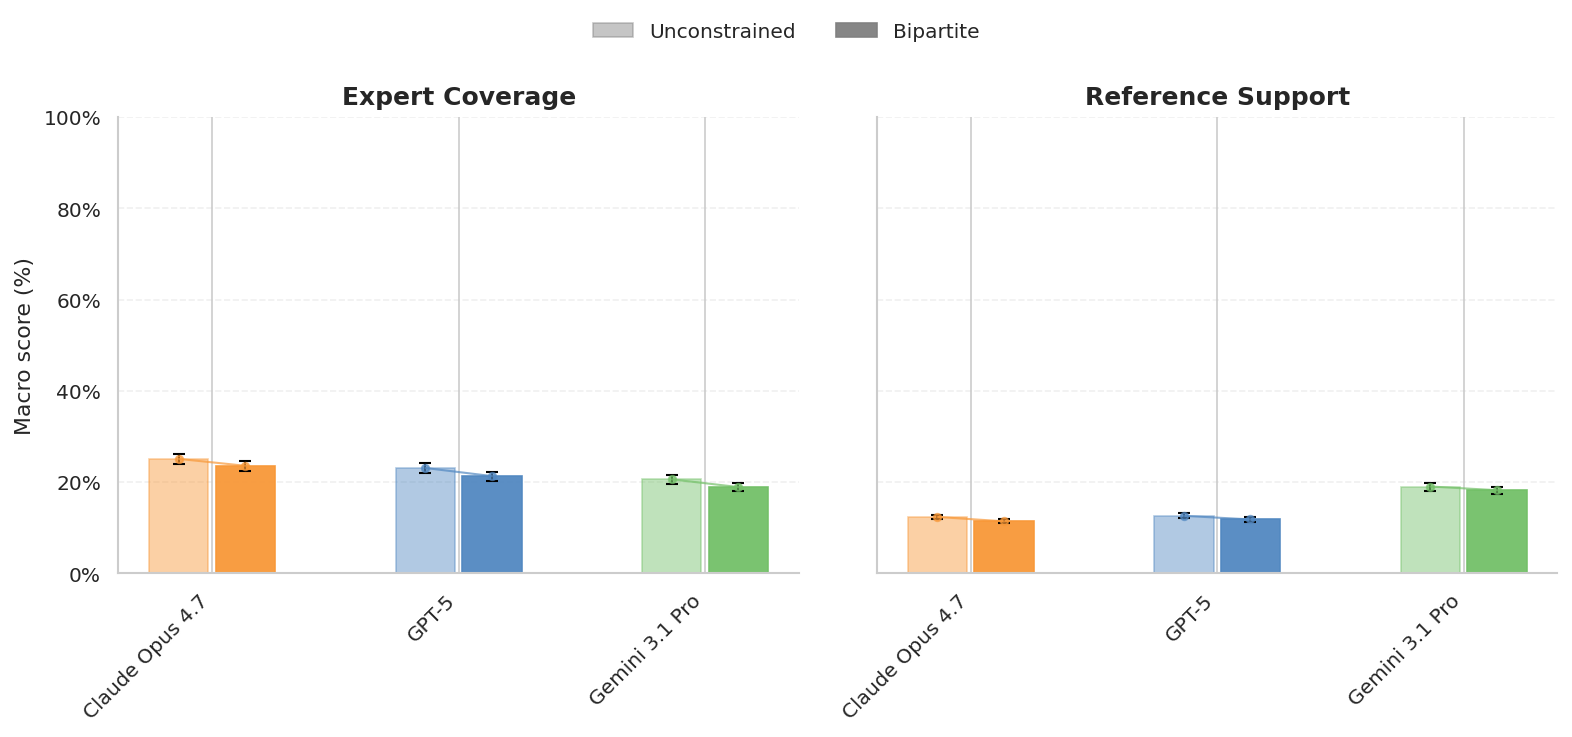

In [6]:
def bootstrap_macro_ci(
    screen_df: pd.DataFrame,
    metric_cols: list[str],
    *,
    iterations: int = BOOTSTRAP_ITERATIONS,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    """Resample apps (not screens) within each model to respect app-level clustering."""
    rng = np.random.default_rng(seed)
    rows = []

    for keys, model_df in screen_df.groupby(MODEL_GROUP_COLS, sort=False):
        key_dict = dict(zip(MODEL_GROUP_COLS, keys))
        app_names = model_df["app_name"].dropna().unique()
        by_app = {app: app_df[metric_cols].to_numpy(dtype=float) for app, app_df in model_df.groupby("app_name", sort=False)}

        boot_values = np.empty((iterations, len(metric_cols)), dtype=float)
        for i in range(iterations):
            sampled_apps = rng.choice(app_names, size=len(app_names), replace=True)
            boot_values[i] = np.nanmean(np.vstack([by_app[app] for app in sampled_apps]), axis=0)

        for j, metric in enumerate(metric_cols):
            low, high = np.percentile(boot_values[:, j], [2.5, 97.5])
            rows.append({
                **key_dict,
                "metric": metric,
                "point_estimate": float(model_df[metric].mean()),
                "ci_low": float(low),
                "ci_high": float(high),
                "bootstrap_iterations": iterations,
            })

    return pd.DataFrame(rows)


core_ci = bootstrap_macro_ci(screen_metrics, core_metric_cols)

core_ci_pct = core_ci.rename(columns={"point_estimate": "point_estimate_pct", "ci_low": "ci_low_pct", "ci_high": "ci_high_pct"})
core_ci_pct[["point_estimate_pct", "ci_low_pct", "ci_high_pct"]] *= 100
core_ci_pct = core_ci_pct.round(1)
core_ci_pct.to_csv(TABLES_DIR / "macro_core_alignment_bootstrap_ci.csv", index=False, float_format="%.1f")
display(core_ci_pct)

core_metric_groups = {
    "Expert Coverage": {"unconstrained": "unconstrained_expert_coverage", "bipartite": "bipartite_expert_coverage"},
    "Reference Support": {"unconstrained": "unconstrained_reference_support", "bipartite": "bipartite_reference_support"},
}
method_labels = {"unconstrained": "Unconstrained", "bipartite": "Bipartite"}
method_alpha = {"unconstrained": 0.45, "bipartite": 0.95}

bar_width = 0.24
x_centers = np.arange(len(MODEL_ORDER), dtype=float)
method_offsets = {"unconstrained": -(bar_width + 0.03) / 2, "bipartite": (bar_width + 0.03) / 2}

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.8), sharey=True)
for ax, (panel_title, metrics) in zip(axes, core_metric_groups.items()):
    for model_idx, model in enumerate(MODEL_ORDER):
        color = MODEL_COLORS[model]
        model_rows = core_ci[core_ci["model_short"].eq(model)].set_index("metric")

        for method, metric in metrics.items():
            row = model_rows.loc[metric]
            x = x_centers[model_idx] + method_offsets[method]
            y = row["point_estimate"]
            ax.bar(x, y, width=bar_width, color=color, alpha=method_alpha[method], edgecolor=color, linewidth=0.8)
            ax.errorbar(
                x, y,
                yerr=[[y - row["ci_low"]], [row["ci_high"] - y]],
                fmt="none", color="black", capsize=3, linewidth=1,
            )

        ax.plot(
            [x_centers[model_idx] + method_offsets[method] for method in method_labels],
            [model_rows.loc[metrics[method], "point_estimate"] for method in method_labels],
            marker="o", markersize=3.5, color=color, alpha=0.7, linewidth=1,
        )

    ax.set_title(panel_title, fontsize=12, weight="bold")
    ax.set_xticks(x_centers)
    ax.set_xticklabels([MODEL_DISPLAY[model] for model in MODEL_ORDER], rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

axes[0].set_ylabel("Macro score (%)")
axes[0].set_ylim(0, 1)
fig.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color="gray", alpha=method_alpha[m], label=method_labels[m]) for m in method_labels],
    loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=2, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_figure("macro_core_alignment_metrics_barplot.png", fig)

### 2.2 Fixed-K Bipartite Budget Control

At each threshold $K$, bipartite expert coverage and reference support are recomputed using only the first $K$ generated critiques for each screen--task instance.

,model_short,model_name,k,bipartite_expert_coverage_pct,bipartite_reference_support_pct
0,claude4_7,Claude Opus 4.7,1,5.4,16.6
1,claude4_7,Claude Opus 4.7,3,12.8,13.3
2,claude4_7,Claude Opus 4.7,5,18.6,11.9
3,gpt5,GPT-5,1,5.0,15.2
4,gpt5,GPT-5,3,12.4,13.0
5,gpt5,GPT-5,5,18.1,12.3
6,gemini3_1pro,Gemini 3.1 Pro,1,7.4,22.6
7,gemini3_1pro,Gemini 3.1 Pro,3,16.9,18.7
8,gemini3_1pro,Gemini 3.1 Pro,5,18.9,18.2


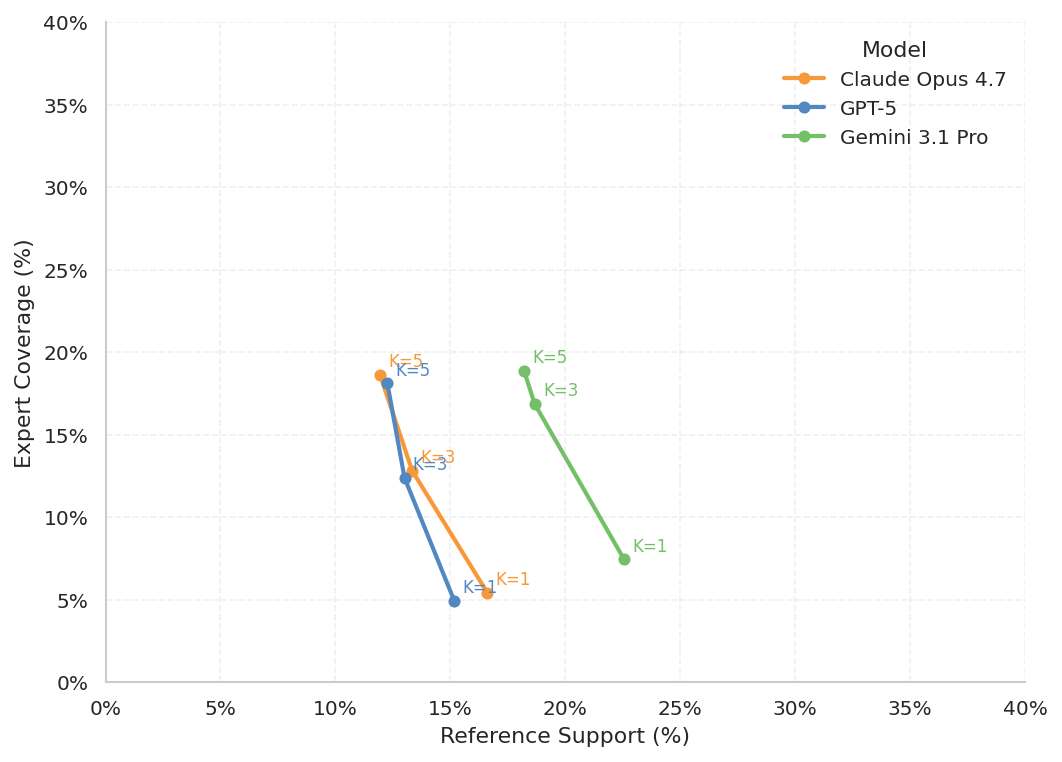

In [7]:
fixed_k_metric_cols = ["bipartite_expert_coverage", "bipartite_reference_support"]
fixed_k_metrics = (
    k_screen_metrics.groupby([*MODEL_GROUP_COLS, "k"], sort=False)[fixed_k_metric_cols].mean().reset_index()
)

fixed_k_metrics_pct = as_percent(fixed_k_metrics, fixed_k_metric_cols)
fixed_k_metrics_pct.to_csv(TABLES_DIR / "fixed_k_macro_bipartite_metrics.csv", index=False, float_format="%.1f")
display(fixed_k_metrics_pct)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
for model in MODEL_ORDER:
    model_line = fixed_k_metrics[fixed_k_metrics["model_short"].eq(model)].sort_values("k")
    ax.plot(
        model_line["bipartite_reference_support"],
        model_line["bipartite_expert_coverage"],
        marker="o", linewidth=2, color=MODEL_COLORS[model], label=MODEL_DISPLAY[model],
    )
    for row in model_line.itertuples(index=False):
        ax.annotate(
            f"K={row.k}",
            (row.bipartite_reference_support, row.bipartite_expert_coverage),
            xytext=(4, 4), textcoords="offset points", fontsize=8, color=MODEL_COLORS[model],
        )
ax.set_xlabel("Reference Support (%)")
ax.set_ylabel("Expert Coverage (%)")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_xlim(0, 0.4)
ax.set_ylim(0, 0.4)
ax.grid(linestyle="--", alpha=0.3)
ax.legend(title="Model", frameon=False)
fig.tight_layout()
save_figure("fixed_k_bipartite_coverage_vs_support.png", fig)

## 3. Judge Diagnostic Flags

Before choosing a relation, each judge answers five intermediate questions per pair with `yes`, `no` or `partial`:
`same_target_element`, `same_usability_problem`, `comment_a_depends_on_unseen_interaction` (expert comment),
`comment_b_depends_on_unseen_interaction` (LLM comment) and `logical_conflict`. Notebook 01 finalizes each flag like the
relation: a value both judges agree on is kept, otherwise the value of the judge whose relation became final is used, and
it is `disagree` when the judges agree on the relation but not on the flag. Manually overridden pairs take
`same_usability_problem` and `logical_conflict` from the manual relation.

The flags are judge outputs, not ground truth: 3.1 checks how far they can be trusted, and 4.2.2 audits the case that
3.2 relies on.

### 3.1 Flag Aggregation and Reliability

#### 3.1.1 Inter-Judge Agreement

Raw agreement and Cohen's κ between the two judges per flag over all pairs of each run, with the relation for reference.
κ corrects for the dominant `no` answers. Flags with κ below `FLAG_KAPPA_MIN` in any run are reported but not interpreted.

In [ ]:
from sklearn.metrics import cohen_kappa_score

FLAG_KAPPA_MIN = 0.4
left_judge, right_judge = JUDGES

flag_agreement_df = pd.DataFrame([
    {
        **dict(zip(MODEL_GROUP_COLS, keys)),
        "field": field,
        "agreement_pct": 100 * df[f"{field}__{left_judge}"].eq(df[f"{field}__{right_judge}"]).mean(),
        "cohen_kappa": cohen_kappa_score(df[f"{field}__{left_judge}"], df[f"{field}__{right_judge}"]),
    }
    for keys, df in pair_labels_df.groupby(MODEL_GROUP_COLS, sort=False)
    for field in ["relation", *DIAGNOSTIC_COLUMNS]
])
flag_agreement_df.round(3).to_csv(TABLES_DIR / "judge_flag_agreement.csv", index=False)

low_kappa_flags = sorted(set(flag_agreement_df.loc[flag_agreement_df["cohen_kappa"].lt(FLAG_KAPPA_MIN), "field"]))
print(f"{left_judge} vs {right_judge}; fields with κ < {FLAG_KAPPA_MIN} in some run: {low_kappa_flags or 'none'}")
flag_agreement_df.pivot(index="field", columns="model_name", values=["cohen_kappa", "agreement_pct"]).reindex(
    ["relation", *DIAGNOSTIC_COLUMNS]
).round(2)

#### 3.1.2 Flag–Relation Consistency

`same_usability_problem` and `logical_conflict` follow from the relation (`RELATION_DIAGNOSTICS`; a contradiction implies no
`same_usability_problem` value). The table gives the share of each judge's own pairs whose flag matches what its own relation
implies, followed by the final relation against the final `same_usability_problem` flag.

In [ ]:
flag_consistency_df = pd.DataFrame([
    {
        **dict(zip(MODEL_GROUP_COLS, keys)),
        "judge": judge,
        "flag": flag,
        "consistent_pct": 100 * df.loc[expected.notna(), f"{flag}__{judge}"].eq(expected.dropna()).mean(),
    }
    for keys, df in pair_labels_df.groupby(MODEL_GROUP_COLS, sort=False)
    for judge in JUDGES
    for flag, implied in RELATION_DIAGNOSTICS.items()
    for expected in [df[f"relation__{judge}"].map(implied)]
])
display(flag_consistency_df.pivot(index=["judge", "flag"], columns="model_name", values="consistent_pct").round(1))

(
    pd.crosstab(pair_labels_df["relation"], pair_labels_df["same_usability_problem"], normalize="index")
    .reindex(RELATION_ORDER)
    .mul(100)
    .round(1)
)

### 3.2 Decomposing Expert-Comment Non-Coverage

An expert comment counts as covered when its best relation carries positive weight (`equivalent`, `llm_broader`,
`human_broader` or `partial_overlap`). Each uncovered expert comment is assigned the first case that any of its pairs with
the model's comments on the same screen-task satisfies:

1. `same_problem_same_element`: shared problem on the same element (`yes`/`partial`), but not enough for a covering relation
2. `same_problem_different_element`: shared problem on a different element (`no`), e.g. low contrast on one button versus another
3. `same_element_different_problem`: same element (`yes`/`partial`) with a different problem (`no`)
4. `neither`: no pair qualifies for 1–3; the closest candidates for genuine omissions

A problem counts as shared when `same_usability_problem` is `yes` or `partial`. The judges reserve `yes` almost entirely
for covering relations (3.1.2), so uncovered pairs that share an issue type show up as `partial`. `disagree` never counts,
which keeps the cases conservative. Relaxed coverage adds case 2 to the covered comments. The shares are pooled over expert
comments and are not directly comparable with the macro-averaged, relation-weighted coverage of Section 2; the strict and
relaxed coverage columns compare like with like.

In [ ]:
COVERED_RELATIONS = [relation for relation, weight in RELATION_WEIGHTS.items() if weight > 0]
SHARED_PROBLEM = ["yes", "partial"]
SAME_ELEMENT = ["yes", "partial"]
NON_COVERAGE_CASES = {
    "same_problem_same_element": lambda d: d["same_usability_problem"].isin(SHARED_PROBLEM) & d["same_target_element"].isin(SAME_ELEMENT),
    "same_problem_different_element": lambda d: d["same_usability_problem"].isin(SHARED_PROBLEM) & d["same_target_element"].eq("no"),
    "same_element_different_problem": lambda d: d["same_usability_problem"].eq("no") & d["same_target_element"].isin(SAME_ELEMENT),
}
COVERAGE_CASE_ORDER = ["covered", *NON_COVERAGE_CASES, "neither"]

covered = expert_coverage_df["best_relation"].isin(COVERED_RELATIONS)
uncovered_pairs_df = metric_pairs_df.merge(expert_coverage_df.loc[~covered, EXPERT_GROUP_COLS], on=EXPERT_GROUP_COLS)
case_hits = pd.DataFrame({case: rule(uncovered_pairs_df) for case, rule in NON_COVERAGE_CASES.items()})
case_hits = case_hits.groupby([uncovered_pairs_df[col] for col in EXPERT_GROUP_COLS]).any()
coverage_case = case_hits.idxmax(axis=1).where(case_hits.any(axis=1), "neither").rename("coverage_case").reset_index()

expert_coverage_df = expert_coverage_df.drop(columns="coverage_case", errors="ignore").merge(
    coverage_case, on=EXPERT_GROUP_COLS, how="left"
)
expert_coverage_df["coverage_case"] = expert_coverage_df["coverage_case"].where(~covered, "covered")

non_coverage_df = (
    pd.crosstab([expert_coverage_df[col] for col in MODEL_GROUP_COLS], expert_coverage_df["coverage_case"], normalize="index")
    .reindex(columns=COVERAGE_CASE_ORDER, fill_value=0)
    .mul(100)
)
non_coverage_df["strict_coverage_pct"] = non_coverage_df["covered"]
non_coverage_df["relaxed_coverage_pct"] = non_coverage_df["covered"] + non_coverage_df["same_problem_different_element"]
non_coverage_df = non_coverage_df.round(1).reset_index().sort_values("model_short", key=lambda s: s.map(MODEL_RANK))
non_coverage_df.to_csv(TABLES_DIR / "expert_non_coverage_cases.csv", index=False)

display_df(non_coverage_df)

### 3.3 Static-Screenshot Limits

The interaction flags are judged per pair, so each comment takes the majority value over its pairs: an expert (LLM)
comment is interaction-dependent when more than half of its pairs mark it `yes`. Coverage and reference support here are
the categorical shares of comments whose best relation is covering.

In [ ]:
def interaction_dependent(flag: str, group_cols: list[str]) -> pd.DataFrame:
    """Majority vote of a per-pair interaction flag for each comment."""
    return (
        metric_pairs_df[flag].eq("yes").groupby([metric_pairs_df[col] for col in group_cols]).mean()
        .gt(0.5).rename("interaction_dependent").reset_index()
    )


def dependency_summary(df: pd.DataFrame, rate_col: str) -> pd.DataFrame:
    """Per model: share of interaction-dependent comments and the rate among dependent and other comments."""
    dependent = df["interaction_dependent"]
    return (
        df.assign(dependent=dependent * 100, rate=df[rate_col] * 100,
                  rate_dependent=(df[rate_col] * 100).where(dependent),
                  rate_other=(df[rate_col] * 100).where(~dependent))
        .groupby(MODEL_GROUP_COLS, sort=False)
        .agg(comments=("dependent", "size"), interaction_dependent_pct=("dependent", "mean"),
             **{f"{rate_col}_pct": ("rate", "mean"), f"{rate_col}_dependent_pct": ("rate_dependent", "mean"),
                f"{rate_col}_other_pct": ("rate_other", "mean")})
        .round(1)
        .reset_index()
    )

#### 3.3.1 Expert Comments Depending on Unseen Interaction

`coverage_other_pct` is the coverage once interaction-dependent expert comments are excluded.

In [ ]:
expert_coverage_df = expert_coverage_df.drop(columns="interaction_dependent", errors="ignore").merge(
    interaction_dependent("comment_a_depends_on_unseen_interaction", EXPERT_GROUP_COLS), on=EXPERT_GROUP_COLS, how="left"
)
expert_dependency_df = dependency_summary(expert_coverage_df.assign(coverage=covered), "coverage")
expert_dependency_df.to_csv(TABLES_DIR / "expert_interaction_dependency.csv", index=False)
display_df(expert_dependency_df)

#### 3.3.2 LLM Comments Depending on Unseen Interaction

LLM comments that speculate about interactions, transitions or hidden content the screenshot does not show.

In [ ]:
llm_support_df = best_ranked_relation(metric_pairs_df, LLM_GROUP_COLS)[[*LLM_GROUP_COLS, "relation"]].merge(
    interaction_dependent("comment_b_depends_on_unseen_interaction", LLM_GROUP_COLS), on=LLM_GROUP_COLS
)
llm_support_df["reference_support"] = llm_support_df["relation"].isin(COVERED_RELATIONS)
llm_dependency_df = dependency_summary(llm_support_df, "reference_support")
llm_dependency_df.to_csv(TABLES_DIR / "llm_interaction_dependency.csv", index=False)
display_df(llm_dependency_df)

### 3.4 Contradiction Analysis

#### 3.4.1 Contradiction Rates

In [8]:
contradiction_summary = (
    pairs.assign(is_contradiction=pairs["relation"].eq("contradiction"))
    .groupby(MODEL_GROUP_COLS, sort=False)
    .apply(
        lambda g: pd.Series({
            "llm_comments": g["llm_comment_id"].nunique(),
            "contradiction_pairs": int(g["is_contradiction"].sum()),
            "llm_comments_with_contradiction": g.loc[g["is_contradiction"], "llm_comment_id"].nunique(),
        }),
        include_groups=False,
    )
    .reset_index()
)
contradiction_summary["contradiction_llm_comment_rate_pct"] = 100 * (
    contradiction_summary["llm_comments_with_contradiction"] / contradiction_summary["llm_comments"]
)
contradiction_summary = contradiction_summary.round(2)
contradiction_summary.to_csv(TABLES_DIR / "contradiction_summary.csv", index=False, float_format="%.2f")
contradiction_summary


,model_short,model_name,llm_comments,contradiction_pairs,llm_comments_with_contradiction,contradiction_llm_comment_rate_pct
0,claude4_7,Claude Opus 4.7,20149,44,42,0.21
1,gpt5,GPT-5,17892,46,46,0.26
2,gemini3_1pro,Gemini 3.1 Pro,9978,18,18,0.18


#### 3.4.2 Logical Conflict vs. the Contradiction Label

How often the final `contradiction` label coincides with the `logical_conflict` flag. Manually overridden pairs agree by
construction, so the comparison is driven by the judges' own answers.

In [ ]:
display(pd.crosstab(
    [pair_labels_df["model_name"], pair_labels_df["relation"].eq("contradiction").rename("contradiction_label")],
    pair_labels_df["logical_conflict"],
    margins=True,
))

## 4. Qualitative Analysis

### 4.0 Review Setup

Shared machinery for the four manual audits (4.1 matched, 4.2 unmatched expert, 4.3 unsupported, 4.4 contradiction).

- **Codebook.** `qualitative_codebook.yaml` (next to this notebook) defines the unit, the coded fields and their allowed
  values per audit; it doubles as the codebook table in the thesis appendix. `save_review` rejects values not in it.
- **Samples.** Each audit draws one frozen sample of `REVIEW_SAMPLE_SIZE` rows per model, stratified by `app_category`, into
  `qualitative_examples/<section>_review_sample.csv`. The same file holds the codes, an `exemplar` flag and a `note`.
  The population size and seed of each draw are recorded in `qualitative_examples/sampling.json`. Delete a sample file
  to redraw it (this discards its codes).
- **Coding loop.** Run the show cell: it displays the next unreviewed row, the allowed values and a prefilled
  `save_review(...)` line. Copy that line into the save cell, fill it in, run it, then run the show cell again.
  Pass `index=` to revisit a row. Notes follow one shape: *what I see -> why these codes*.
- **Thesis text.** 4.5 tabulates the codes. Numbers in the thesis come from those tables; examples are cited by
  section, model and `sample_index`.

In [ ]:
import json

import yaml

REVIEW_SAMPLE_SIZE = 50  # rows per model
REVIEW_SECTIONS = ["matched", "unmatched", "unsupported", "contradiction"]
REVIEW_SAMPLE_PATHS = {section: QUALITATIVE_DIR / f"{section}_review_sample.csv" for section in REVIEW_SECTIONS}
SAMPLING_PATH = QUALITATIVE_DIR / "sampling.json"
CODEBOOK = yaml.safe_load((NOTEBOOK_DIR / "qualitative_codebook.yaml").read_text())
REVIEW_FIELDS = {section: list(CODEBOOK[section]["fields"]) for section in REVIEW_SECTIONS}
UNCOVERED_RELATIONS = ["related_but_different", "no_match"]
SAMPLE_COLUMNS = [
    "model_short", "model_name", "pair_id", "screen_task_id", "expert_comment_id", "llm_comment_id",
    "screen_id", "app_category", "task", "relation", "confidence",
    "expert_observed_issue", "expert_suggested_fix", "expert_bounding_box",
    "llm_expected_standard", "llm_observed_issue", "llm_suggested_fix",
    "other_models_covered", "coverage_case",
]


def review_population(section):
    """Rows a section samples from: pairs (matched, contradiction), LLM comments (unsupported) or expert comments (unmatched)."""
    if section in {"matched", "contradiction"}:
        relation = "equivalent" if section == "matched" else "contradiction"
        return metric_pairs_df[metric_pairs_df["relation"].eq(relation)]
    if section == "unsupported":
        best_df = best_ranked_relation(metric_pairs_df, LLM_GROUP_COLS)
        return best_df[best_df["relation"].eq("no_match")]
    # unmatched: the best pair of each uncovered expert comment, plus how many other models covered it.
    other_models_covered = (
        expert_coverage_df["coverage_case"].eq("covered")
        .groupby([expert_coverage_df["screen_task_id"], expert_coverage_df["expert_comment_id"]]).sum()
        .rename("other_models_covered").reset_index()
    )
    best_df = best_ranked_relation(metric_pairs_df, EXPERT_GROUP_COLS)
    return (
        best_df[best_df["relation"].isin(UNCOVERED_RELATIONS)]
        .merge(other_models_covered, on=["screen_task_id", "expert_comment_id"])
        .merge(expert_coverage_df[[*EXPERT_GROUP_COLS, "coverage_case"]], on=EXPERT_GROUP_COLS)
    )


def stratified_sample_pairs(df, n=15, seed=RANDOM_SEED):
    """Take one pair per app category first, then top up at random to n rows."""
    df = df.dropna(subset=["llm_observed_issue"]).drop_duplicates(subset="pair_id").copy()
    if df.empty:
        return df

    df["app_category"] = df["app_category"].fillna("Unknown")
    n = min(n, len(df))

    sample_df = pd.concat(
        [group_df.sample(1, random_state=seed) for _, group_df in df.groupby("app_category", sort=True)]
    )
    sample_df = sample_df.sample(frac=1, random_state=seed).head(n)

    remaining_n = n - len(sample_df)
    if remaining_n > 0:
        remaining_df = df.drop(index=sample_df.index)
        sample_df = pd.concat([sample_df, remaining_df.sample(n=min(remaining_n, len(remaining_df)), random_state=seed)])

    return sample_df.sample(frac=1, random_state=seed).reset_index(drop=True)


def load_or_create_review_sample(section, n=REVIEW_SAMPLE_SIZE, seed=RANDOM_SEED):
    """Return the frozen review sample of a section with its code columns, drawing it once if absent."""
    path = REVIEW_SAMPLE_PATHS[section]
    if not path.exists():
        source_df = review_population(section)
        source_df = source_df[[col for col in SAMPLE_COLUMNS if col in source_df]]
        samples = []
        for model in MODEL_ORDER:
            model_sample_df = stratified_sample_pairs(source_df[source_df["model_short"].eq(model)], n=n, seed=seed)
            model_sample_df.insert(2, "sample_index", range(len(model_sample_df)))
            samples.append(model_sample_df)
        pd.concat(samples, ignore_index=True).to_csv(path, index=False)

        sampling = json.loads(SAMPLING_PATH.read_text()) if SAMPLING_PATH.exists() else {}
        sampling[section] = {
            "population": {model: int(source_df["model_short"].eq(model).sum()) for model in MODEL_ORDER},
            "sample_per_model": n,
            "seed": seed,
            "stratified_by": "app_category",
        }
        SAMPLING_PATH.write_text(json.dumps(sampling, indent=2))
        print(f"Froze {n} rows per model to {path}")

    code_cols = [*REVIEW_FIELDS[section], "exemplar", "note"]
    sample_df = pd.read_csv(path)
    for col in code_cols:
        if col not in sample_df:
            sample_df[col] = pd.NA
    return sample_df.astype({col: "object" for col in code_cols})


EXPERT_BOXES = metric_pairs_df.drop_duplicates("expert_comment_id").set_index("expert_comment_id")["expert_bounding_box"]
PAIR_FLAGS = metric_pairs_df.set_index(["model_short", "pair_id"])[DIAGNOSTIC_COLUMNS]


def print_model_comments(row):
    """All of the model's comments on the row's screen, across tasks; judged pairs first, best relation first."""
    comments_df = (
        metric_pairs_df[metric_pairs_df["model_short"].eq(row["model_short"]) & metric_pairs_df["screen_id"].eq(row["screen_id"])]
        .drop_duplicates("llm_comment_id")[["screen_task_id", "llm_comment_id", "llm_observed_issue"]]
        .merge(
            metric_pairs_df.loc[
                metric_pairs_df["model_short"].eq(row["model_short"]) & metric_pairs_df["expert_comment_id"].eq(row["expert_comment_id"]),
                ["llm_comment_id", "relation", "confidence"],
            ],
            on="llm_comment_id", how="left",
        )
    )
    comments_df = comments_df.assign(
        other_task=comments_df["screen_task_id"].ne(row["screen_task_id"]),
        relation_rank=comments_df["relation"].map(RELATION_RANK),
    ).sort_values(["other_task", "screen_task_id", "relation_rank", "confidence"], ascending=[True, True, True, False])
    print(f"\nAll {row['model_name']} comments on this screen:")
    for i, comment in enumerate(comments_df.itertuples(), start=1):
        judged = f"{comment.relation}, {comment.confidence:.2f}" if not comment.other_task else f"{comment.screen_task_id}, not judged"
        print(f"  {i}. [{judged}] {comment.llm_observed_issue}")


def show_comment_for_review(section, model="claude4_7", index=None):
    """Display one sampled row (the first unreviewed by default) and remember it for the next save_review call."""
    global current_review
    fields = REVIEW_FIELDS[section]
    sample_df = load_or_create_review_sample(section)
    model_sample_df = sample_df[sample_df["model_short"].eq(model)].sort_values("sample_index")
    if index is None:
        unreviewed = np.flatnonzero(model_sample_df[fields[0]].isna())
        if not len(unreviewed):
            print(f"All {len(model_sample_df)} {section} rows of {model} are reviewed.")
            return
        index = unreviewed[0]
    if not 0 <= index < len(model_sample_df):
        raise IndexError(f"index must be between 0 and {len(model_sample_df) - 1}")

    row = model_sample_df.iloc[index]
    current_review = (section, row.name)

    print(f"{index + 1}/{len(model_sample_df)} {section} ({row['relation']}) - {model} | {row['app_category']} | screen {row['screen_id']}")
    print("Task:", row["task"])
    # The unsupported review is deliberately blind to the expert comment.
    if section != "unsupported":
        print("Expert comment:", row["expert_observed_issue"])
    if section == "matched":
        print("Expert fix:", row["expert_suggested_fix"])
    if section == "unmatched":
        print(f"Covered by {row['other_models_covered']} other model(s); judge case: {row['coverage_case']}")
        print_model_comments(row)
    else:
        if section != "unsupported" and (model, row["pair_id"]) in PAIR_FLAGS.index:
            flags = PAIR_FLAGS.loc[(model, row["pair_id"])]
            print("Judge flags:", ", ".join(f"{flag}={value}" for flag, value in flags.items()))
        for label, col in [("LLM standard", "llm_expected_standard"), ("LLM comment", "llm_observed_issue"), ("LLM fix", "llm_suggested_fix")]:
            if col in row:
                print(f"{label}:", row[col])

    print()
    for field in fields:
        print(f"{field}: {' | '.join(map(str, CODEBOOK[section]['fields'][field]))}")
    codes = ", ".join(f"{field}={None if pd.isna(row[field]) else row[field]!r}" for field in fields)
    note = "" if pd.isna(row["note"]) else row["note"]
    print(f"save_review({codes}, note={note!r})")

    expert_bbox = None
    if section != "unsupported":
        expert_bbox = row.get("expert_bounding_box")
        if pd.isna(expert_bbox):
            expert_bbox = EXPERT_BOXES.get(row["expert_comment_id"])
    has_bbox = not pd.isna(expert_bbox)
    show_screen(
        screen_id=row["screen_id"],
        bboxes=[expert_bbox] if has_bbox else None,
        labels=["Expert comment"] if has_bbox else None,
        colors=["tab:red"],
        width=250,
    )


def save_review(note="", exemplar=False, **codes):
    """Write the codes for the row most recently shown into its sample file."""
    if all(value is None for value in codes.values()):
        print("No codes set; nothing saved.")
        return
    section, position = current_review
    allowed = CODEBOOK[section]["fields"]
    if set(codes) != set(allowed):
        raise ValueError(f"{section} takes exactly these codes: {list(allowed)}")
    for field, value in codes.items():
        if str(value) not in map(str, allowed[field]):
            raise ValueError(f"{field}={value!r} is not one of {list(allowed[field])}")

    sample_df = load_or_create_review_sample(section)
    sample_df.loc[position, [*codes, "exemplar", "note"]] = [*codes.values(), exemplar, note]
    sample_df.to_csv(REVIEW_SAMPLE_PATHS[section], index=False)
    print(f"Saved {sample_df[REVIEW_FIELDS[section][0]].notna().sum()}/{len(sample_df)} {section} reviews")


def review_progress():
    progress = []
    for section in REVIEW_SECTIONS:
        sample_df = load_or_create_review_sample(section)
        progress.append(
            sample_df.groupby("model_short")[REVIEW_FIELDS[section][0]]
            .agg(reviewed="count", total="size")
            .reset_index()
            .assign(section=section)
        )
    progress_df = pd.concat(progress, ignore_index=True)
    progress_df["remaining"] = progress_df["total"] - progress_df["reviewed"]
    return progress_df[["section", "model_short", "reviewed", "remaining"]]


display(review_progress())

### 4.1 Matched Comment Analysis

Review pairs the judge labelled `equivalent`. First check whether the match is real (`match`), then assess the depth
of the LLM's fix against the expert's on the same scale (`llm_fix`, `expert_fix`), whether the fix would work
(`fix_sound`), and the kind of problem (`issue_type`).

In [ ]:
show_comment_for_review("matched", "claude4_7")

In [ ]:
save_review(match=None, llm_fix=None, expert_fix=None, fix_sound=None, issue_type=None, note="")

### 4.2 Unmatched Expert Comment Analysis

Expert comments whose best relation is only `related_but_different` or `no_match`. The counts below cover every model;
the audit samples 50 such comments per model and shows each against all of that model's comments on the
screen, including those written for its other tasks (which the judges never paired with it), so the reviewer first
confirms that none of them covers it and then codes why it was missed (`cause`).
The sample also records how many other models covered the comment and the judge's non-coverage case from 3.2. The
audit is read collectively (cause distribution, shared vs. model-specific misses), not case by case.

In [ ]:
UNMATCHED_EXPERT_RELATIONS = ["related_but_different", "no_match"]


def build_unmatched_expert_comments(relations=UNMATCHED_EXPERT_RELATIONS):
    model_count = len(MODEL_ORDER)
    unmatched_by_model_df = expert_coverage_df[expert_coverage_df["best_relation"].isin(relations)]

    counts_df = (
        unmatched_by_model_df.groupby([*MODEL_GROUP_COLS, "best_relation"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=relations, fill_value=0)
    )
    counts_df["not_matched"] = counts_df.sum(axis=1)
    counts_df["expert_comments"] = expert_coverage_df.groupby(MODEL_GROUP_COLS, observed=True).size()
    counts_df["not_matched_pct"] = (counts_df["not_matched"] / counts_df["expert_comments"] * 100).round(1)
    counts_df = (
        counts_df.reset_index()
        .sort_values("model_short", key=lambda s: s.map(MODEL_RANK))
        .reset_index(drop=True)
    )

    expert_cols = [
        "screen_task_id", "expert_comment_id", "screen_id", "app_category",
        "task", "expert_observed_issue", "expert_bounding_box",
    ]
    all_models_df = (
        unmatched_by_model_df.groupby(["screen_task_id", "expert_comment_id"], as_index=False)
        .agg(models_not_matched=("model_short", "nunique"))
        .query("models_not_matched == @model_count")
        .merge(
            metric_pairs_df[expert_cols].drop_duplicates(["screen_task_id", "expert_comment_id"]),
            on=["screen_task_id", "expert_comment_id"],
            how="left",
        )
        .sort_values(["app_category", "screen_task_id", "expert_comment_id"])
        .reset_index(drop=True)
    )

    return counts_df, all_models_df

In [ ]:
unmatched_expert_counts_df, unmatched_by_all_models_df = build_unmatched_expert_comments()

print("Expert comments not matched per model")
display_df(unmatched_expert_counts_df)

print(f"Expert comments not matched by all three models: {len(unmatched_by_all_models_df):,}")
display_df(unmatched_by_all_models_df[[
    "screen_id", "screen_task_id", "app_category", "expert_comment_id", "expert_observed_issue"
]])

In [ ]:
show_comment_for_review("unmatched", "claude4_7")

In [ ]:
save_review(cause=None, issue_type=None, note="")

#### 4.2.1 Shared Expert-Comment Omissions

We qualitatively inspected a reproducible random sample of 30 unique expert comments that were not covered by any of the three models. Each comment was assessed against the complete interface screenshot, with the expert-provided bounding box treated as the target region rather than as a crop that excluded surrounding interaction context. This sample therefore characterizes shared blind spots across models; it is not an estimate of model-specific failure rates.

The review showed that an unmatched expert comment does not necessarily constitute a clear model failure. Twelve of the 30 comments described a specific, visually localized concern supported by the target region, including insufficient edge margins, small or tightly spaced controls, weak typographic hierarchy, low-contrast text, and ambiguous icons. These cases provide the strongest evidence of shared omissions. Nine comments were dependent on interaction context or design conventions that could not be resolved from a static screenshot alone. This group included claims about missing Back or Cancel controls, the need to scroll, and insufficient information about an application's purpose. Five comments were broad or subjective (for example, that colours were unappealing, the layout was basic, or the composition lacked balance), making exact semantic recovery unlikely even when a model identified more concrete problems in the same region. The remaining four appeared inconsistent with the visible evidence: two reported spelling or icon-detail defects not present in the target region, one claimed that an icon-rich screen lacked icons, and one characterized a simple heart symbol as overly detailed.

The model outputs also revealed several near misses hidden by the categorical coverage score. For example, models identified weak contrast and grid imbalance where the expert used the broader description of unappealing colours and a basic layout; they identified weak hierarchy in the same navigation drawer where the expert compared heading and menu typography; and they criticized the date picker's low contrast and unclear operation while omitting the expert's specific request for a Cancel action. Conversely, some highly localized concerns, such as edge margins, control size and spacing, and small low-contrast text, were not recovered despite being visually verifiable. Thus, disagreement arose from at least three sources: genuine omission of an expert-identified issue, different but defensible prioritization of another problem in the same target area, and noise or underspecification in the expert reference itself.

A recurring form of near miss involved the same issue type applied to different interface elements. On the same screen, the expert and the model often raised the same kind of problem, such as insufficient contrast, but attached it to different elements (for example, the contrast of one button versus another). Because a match requires the same issue on the same target, such pairs are labelled `no_match` or `related_but_different` and do not count towards coverage. The low expert-comment coverage (around 25%) therefore partly reflects element-level disagreement rather than a failure to recognize the underlying issue type. This qualifies the coverage figure rather than overturning it: the element-specific problems the expert raised were still missed.

> TODO: Support this paragraph with the share of `same_problem_different_element` expert comments and the relaxed coverage from 3.2, once the 4.2.2 audit confirms the flag, and cite 2–3 audited pairs. First run: case 2 covers only about 1–2% of expert comments per model, and a shared problem on the same or partly the same element about 4–6%. Size the claim to these numbers.

These findings qualify the interpretation of expert-comment recall. Treating every unmatched expert statement as a false negative would overstate model unreliability because the expert annotations are not uniformly specific, observable, or correct. At the same time, the repeated omission of concrete accessibility and interaction details shows that fluent critique generation does not guarantee comprehensive expert alignment. Reliability should therefore be reported along two axes: coverage of valid expert concerns and reference support of the models' additional critiques. A manual audit should code reference validity, visual observability, semantic near misses, and model-specific omissions before unmatched comments are used as evidence of failure.

For the main qualitative analysis, the sampling unit should be the normalized usability issue rather than the raw comment string. Near-duplicate expert comments across screens should be clustered, with one randomly selected instance per cluster, to prevent frequent templates such as missing Back navigation from dominating a small sample. Cluster prevalence should nevertheless be retained and reported separately, or used as a sampling weight, because deduplication changes the estimand from the distribution of comments to the diversity of issue types. The 30-comment intersection sample is appropriate for analyzing shared blind spots. A separate model-stratified audit (for example, 30 unmatched comments per model, deduplicated within issue cluster and annotated for whether the other models covered the issue) is required for comparative claims about which model is more reliable.

### 4.3 Unsupported Comment Analysis

LLM comments that are `no_match` against every expert comment in the same screen-task (their best relation is
`no_match`). The review is blind to the expert comments: judge the comment against the screenshot alone and code
whether it is a legitimate observation the expert did not make (`validity`).

In [ ]:
show_comment_for_review("unsupported", "claude4_7")

In [ ]:
save_review(validity=None, issue_type=None, note="")

### 4.4 Contradiction Audit

Focus on:
- true contradiction
- LLM wrong
- expert wrong or incomplete
- both valid under different interpretations
- ambiguity, missing context, or relation extraction issue

In [ ]:
show_comment_for_review("contradiction", "claude4_7")

In [ ]:
save_review(label=None, note="")

### 4.5 Audit Summary

Counts and within-model shares of every coded value over the reviewed rows, saved to `audit_summary-<section>.csv`,
followed by the cross-tabulations the write-up relies on.

In [ ]:
def audit_summary(section):
    """`n (pct%)` of every coded value per model and pooled; reviewed rows only."""
    fields = REVIEW_FIELDS[section]
    reviewed_df = load_or_create_review_sample(section).dropna(subset=fields)
    if reviewed_df.empty:
        return None
    tables = []
    for field in fields:
        counts = pd.crosstab(reviewed_df[field], reviewed_df["model_short"]).reindex(columns=MODEL_ORDER, fill_value=0)
        counts["all"] = counts.sum(axis=1)
        pct = counts.div(counts.sum().replace(0, np.nan)).mul(100).fillna(0).round().astype(int)
        cell_text = counts.astype(str) + " (" + pct.astype(str) + "%)"
        tables.append(cell_text.rename_axis("value").reset_index().assign(field=field))
    summary_df = pd.concat(tables, ignore_index=True)[["field", "value", *MODEL_ORDER, "all"]]
    summary_df.to_csv(TABLES_DIR / f"audit_summary-{section}.csv", index=False)
    return summary_df


for section in REVIEW_SECTIONS:
    summary_df = audit_summary(section)
    if summary_df is not None:
        print(section)
        display(summary_df.set_index(["field", "value"]))

matched_review_df = load_or_create_review_sample("matched").dropna(subset=REVIEW_FIELDS["matched"])
unmatched_review_df = load_or_create_review_sample("unmatched").dropna(subset=REVIEW_FIELDS["unmatched"])
if not matched_review_df.empty:
    display(pd.crosstab(matched_review_df["llm_fix"], matched_review_df["expert_fix"], margins=True))
if not unmatched_review_df.empty:
    display(pd.crosstab(unmatched_review_df["cause"], unmatched_review_df["other_models_covered"], margins=True))
    display(pd.crosstab(unmatched_review_df["cause"], unmatched_review_df["coverage_case"], margins=True))

### 4.6 Notes on the Generated Critiques

Notes on the critiques:
- LLMs write detailed comments
- most of it is about visuals
- LLMs focus on atomic things, whereas humans talk about multiple things or generalize rather than being specific

## 5. Guideline Reference Analysis

This section analyzes whether LLM critiques include guideline references and whether referenced critiques have higher reference support.

Run this section only if `llm_guideline_reference` exists in the LLM-comment table. The unit of analysis is the unique LLM comment, not the pair row, so each generated critique contributes once.


### 5.1 Parse References

Reference strings are parsed by `utils.comments.guidelines`, which normalizes source names,
Nielsen heuristics and Apple HIG concepts into one record per cited guideline.

The check below lists any wording the parser could not resolve; new entries belong in
`utils.comments.guidelines`.

In [9]:
refs_df = (
    all_pairs_df[["model_short", "model_name", "llm_comment_id", "llm_guideline_reference"]]
    .drop_duplicates(["model_short", "llm_comment_id"])
    .copy()
)
refs_df["parsed_guideline_references"] = refs_df["llm_guideline_reference"].apply(parse_guideline_references)
parsed_long_df = build_parsed_long_df(refs_df)

print(f"LLM comments: {len(refs_df):,}")
print(f"Missing reference field: {int(refs_df['llm_guideline_reference'].isna().sum()):,}")
print(f"Parsed references: {len(parsed_long_df):,}")

LLM comments: 48,019
Missing reference field: 1
Parsed references: 104,169


In [10]:
def unmapped_reference_wordings(top_n: int = 15) -> pd.DataFrame:
    """Guideline wordings the parser could not resolve, most frequent first.

    An empty result means every reference mapped onto a known source, heuristic or
    Apple HIG concept. Anything listed needs a new alias in utils.comments.guidelines.
    """
    is_nielsen = parsed_long_df["source"].eq("Nielsen")
    is_apple = parsed_long_df["source"].eq("Apple HIG")
    checks = [
        ("unknown source", parsed_long_df["source"], CANONICAL_SOURCES),
        ("unmapped Nielsen category", parsed_long_df["category"].where(is_nielsen), NIELSEN_LOOKUP),
        ("unmapped Apple category", parsed_long_df["category"].where(is_apple), APPLE_TOP_LOOKUP),
        ("unmapped Apple subcategory", parsed_long_df["subcategory"].where(is_apple), APPLE_SUBCATEGORY_PARENT),
    ]

    found = [
        pd.DataFrame({
            "issue": "unparsed reference",
            "value": refs_df.loc[
                refs_df["llm_guideline_reference"].notna() & refs_df["parsed_guideline_references"].str.len().eq(0),
                "llm_guideline_reference",
            ],
        })
    ]
    for issue, values, known in checks:
        values = values.dropna()
        unmapped = values[~values.map(lambda v: (v if issue == "unknown source" else normalize_key(v)) in known)]
        found.append(pd.DataFrame({"issue": issue, "value": unmapped}))

    summary = (
        pd.concat(found)
        .groupby(["issue", "value"], as_index=False)
        .size()
        .sort_values(["issue", "size"], ascending=[True, False])
        .rename(columns={"size": "references"})
    )
    if summary.empty:
        print("No unmapped guideline wordings.")
    return summary.groupby("issue", group_keys=False).head(top_n).reset_index(drop=True)


display(unmapped_reference_wordings())

,issue,value,references
0,unmapped Apple category,Empty States,182
1,unmapped Apple category,Accessibility,51
2,unmapped Apple category,Consistency,45
3,unmapped Apple category,Make interactive elements obvious,40
4,unmapped Apple category,Internationalization,38
5,unmapped Apple category,Visual Hierarchy,32
6,unmapped Apple category,Actions,29
7,unmapped Apple category,Internationalization and Localization,25
8,unmapped Apple category,Visual hierarchy,25
9,unmapped Apple category,App Architecture,20


### 5.2 Reference Presence

Check that every unique LLM comment has a guideline-reference field and at least one parsed reference.


In [11]:
reference_presence_df = refs_df.assign(
    has_guideline_reference=refs_df["llm_guideline_reference"].notna()
    & refs_df["llm_guideline_reference"].astype(str).str.strip().ne(""),
    parsed_reference_count=refs_df["parsed_guideline_references"].str.len(),
)
reference_presence_df["parsed_reference_count_when_present"] = (
    reference_presence_df["parsed_reference_count"].where(reference_presence_df["has_guideline_reference"])
)
reference_presence_df["unparsed_nonmissing_reference"] = (
    reference_presence_df["has_guideline_reference"] & reference_presence_df["parsed_reference_count"].eq(0)
)

guideline_reference_presence_df = (
    reference_presence_df.groupby(MODEL_GROUP_COLS, observed=True)
    .agg(
        llm_comments=("llm_comment_id", "nunique"),
        comments_with_reference=("has_guideline_reference", "sum"),
        min_parsed_references_when_present=("parsed_reference_count_when_present", "min"),
        unparsed_nonmissing_references=("unparsed_nonmissing_reference", "sum"),
    )
    .reset_index()
)
guideline_reference_presence_df["missing_references"] = (
    guideline_reference_presence_df["llm_comments"] - guideline_reference_presence_df["comments_with_reference"]
)
guideline_reference_presence_df = (
    guideline_reference_presence_df
    .sort_values("model_short", key=lambda s: s.map(MODEL_RANK))
    .reset_index(drop=True)
)

assert guideline_reference_presence_df["unparsed_nonmissing_references"].eq(0).all()
display(guideline_reference_presence_df)


,model_short,model_name,llm_comments,comments_with_reference,min_parsed_references_when_present,unparsed_nonmissing_references,missing_references
0,claude4_7,Claude Opus 4.7,20149,20149,1.0,0,0
1,gpt5,GPT-5,17892,17891,1.0,0,1
2,gemini3_1pro,Gemini 3.1 Pro,9978,9978,1.0,0,0


### 5.3 Guideline Focus

This section stays at the unique LLM-comment/reference level and summarizes which guideline concepts were repeatedly cited. All three figures use grouped horizontal bars, consistent model colors, and direct percentage labels so that models can be compared on a common baseline. The category construction remains framework-specific: Nielsen uses its fixed canonical taxonomy, Apple HIG uses a compact set of shared concept bins, and CrowdCrit uses broader focus groups derived from its noisier free-text labels.


In [12]:
def reference_percentage_matrix(df: pd.DataFrame, label_col: str, row_order: list[str]) -> pd.DataFrame:
    """Percentage of each model's references falling in each label, as a label x model matrix."""
    counts = (
        df.dropna(subset=[label_col])
        .groupby([*MODEL_GROUP_COLS, label_col], observed=True)
        .size()
        .rename("reference_count")
        .reset_index()
    )
    counts["pct_references"] = 100 * counts["reference_count"] / counts.groupby(
        "model_short", observed=True
    )["reference_count"].transform("sum")
    return (
        counts.pivot(index=label_col, columns="model_name", values="pct_references")
        .reindex(index=row_order, columns=[MODEL_DISPLAY[model] for model in MODEL_ORDER])
        .fillna(0)
    )


def plot_reference_percentages(plot_df, title, xlabel, filename, figsize=(11, 7.2), legend_loc="best"):
    ax = plot_df.plot.barh(figsize=figsize, width=0.78, color=[model_color(column) for column in plot_df.columns])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)
    ax.legend(title="Model", loc=legend_loc, frameon=False)
    plt.tight_layout()
    save_figure(filename)


#### 5.3.1 Nielsen Heuristic Distribution

The figure presents Nielsen's canonical 10 heuristics in their original numbered order. Each row contains one bar per model, and percentages are calculated within each model's successfully mapped Nielsen references. Non-canonical Nielsen-attributed labels are excluded from this denominator and retained in the parser diagnostics. The shared horizontal scale supports direct comparison while preserving the complete heuristic names.


model_name,Claude Opus 4.7,GPT-5,Gemini 3.1 Pro
category,,,
Visibility of System Status,25.95,12.72,14.42
Match Between the System and the Real World,14.61,14.55,18.72
User Control and Freedom,7.30,3.83,3.50
Consistency and Standards,9.54,21.19,25.84
Error Prevention,5.66,10.60,7.22
Recognition Rather than Recall,17.31,15.23,6.63
Flexibility and Efficiency of Use,4.28,4.08,3.06
Aesthetic and Minimalist Design,9.04,14.51,18.50
"Help Users Recognize, Diagnose, and Recover from Errors",2.59,1.45,0.82


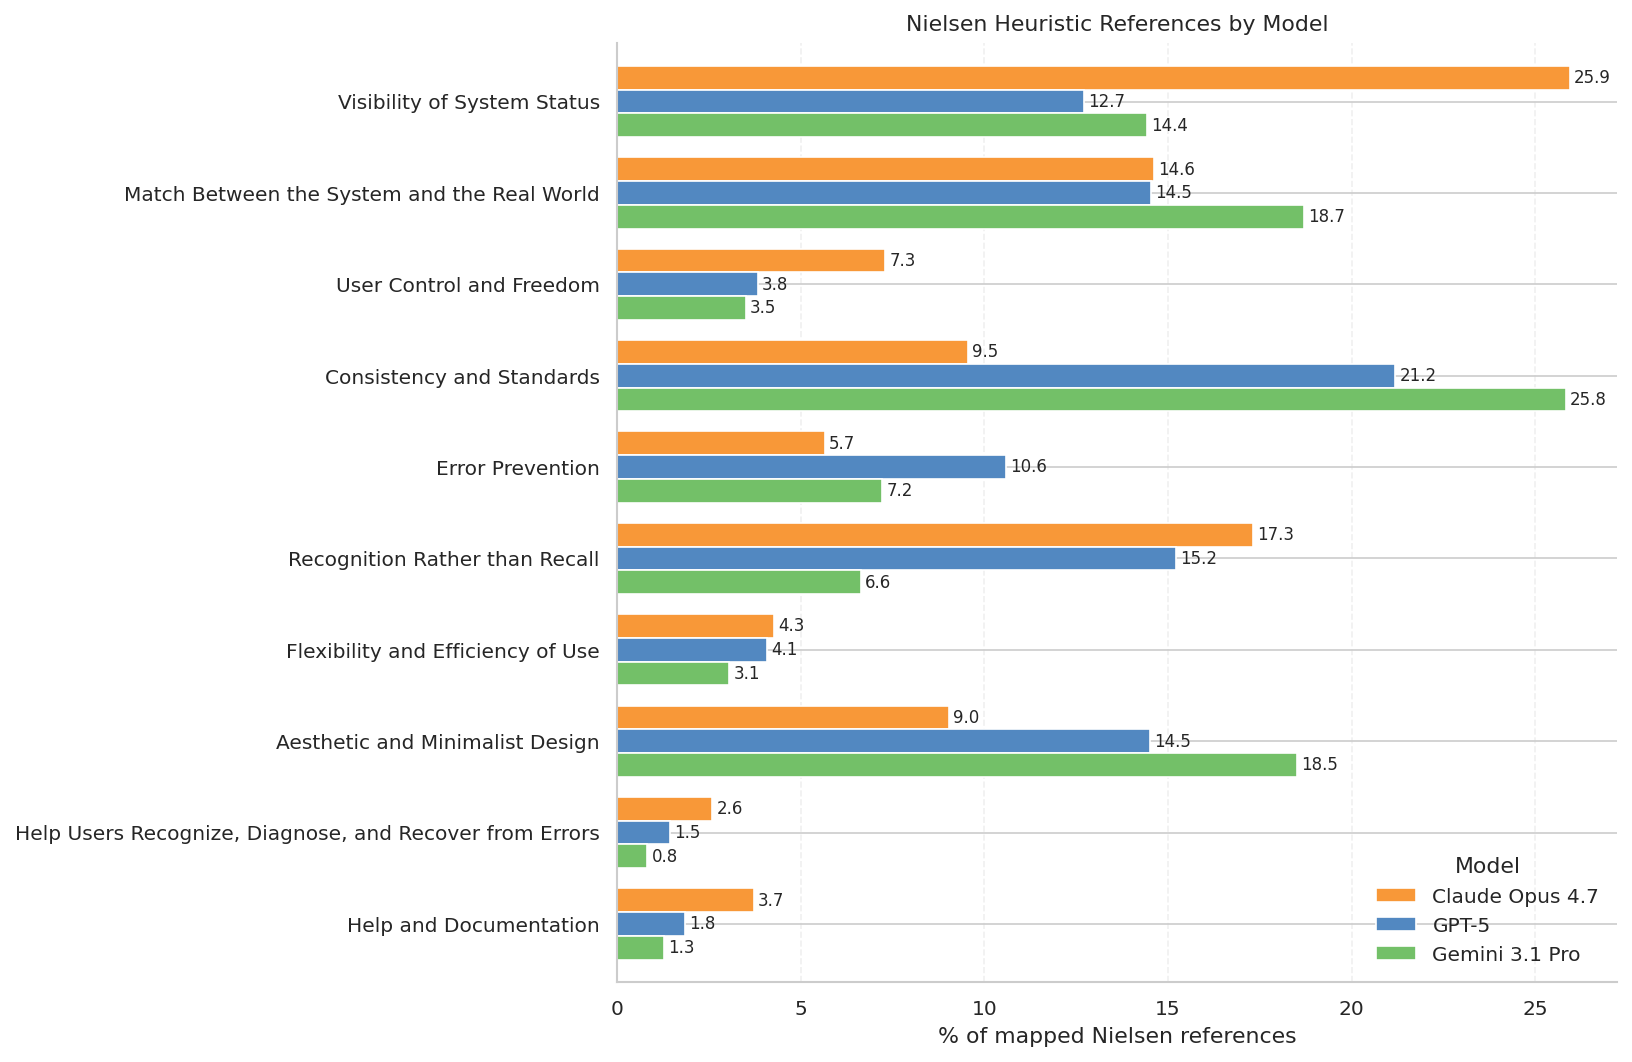

In [13]:
nielsen_refs_df = parsed_long_df.loc[
    parsed_long_df["source"].eq("Nielsen") & parsed_long_df["category"].isin(NIELSEN_CATEGORIES)
]
nielsen_plot_df = reference_percentage_matrix(nielsen_refs_df, "category", NIELSEN_CATEGORIES)

display(nielsen_plot_df.round(2))
plot_reference_percentages(
    nielsen_plot_df,
    "Nielsen Heuristic References by Model",
    "% of mapped Nielsen references",
    "guideline_nielsen.png",
    legend_loc="lower right",
)


#### 5.3.2 Apple HIG Concept Distribution

For reporting, Apple HIG category and subcategory are merged into one derived concept label when the subcategory is known; the underlying parser output is unchanged. The figure uses the nine mapped concepts with the largest pooled reference counts across all three models, ordered by that pooled frequency. A tenth `Other (including unmapped / non-canonical)` bin combines every remaining mapped concept with all unmapped labels. Consequently, the 10 bins are exhaustive and each model's percentages sum to 100% before rounding. The shared bins and horizontal scale permit direct comparisons across models.


model_name,Claude Opus 4.7,GPT-5,Gemini 3.1 Pro
apple_plot_concept,,,
Foundations / Color,9.39,9.86,21.67
Foundations / Layout,14.30,9.11,14.24
Components / Menus and Actions / Buttons,11.66,4.23,13.23
Components / Navigation and Search,10.87,5.57,6.68
Foundations / Writing,3.67,10.67,2.07
Components / System Experiences / Controls,6.07,7.64,1.45
Foundations / Typography,4.30,5.95,8.96
Components / Content,0.61,10.00,0.08
Foundations / Icons,3.80,3.09,8.45


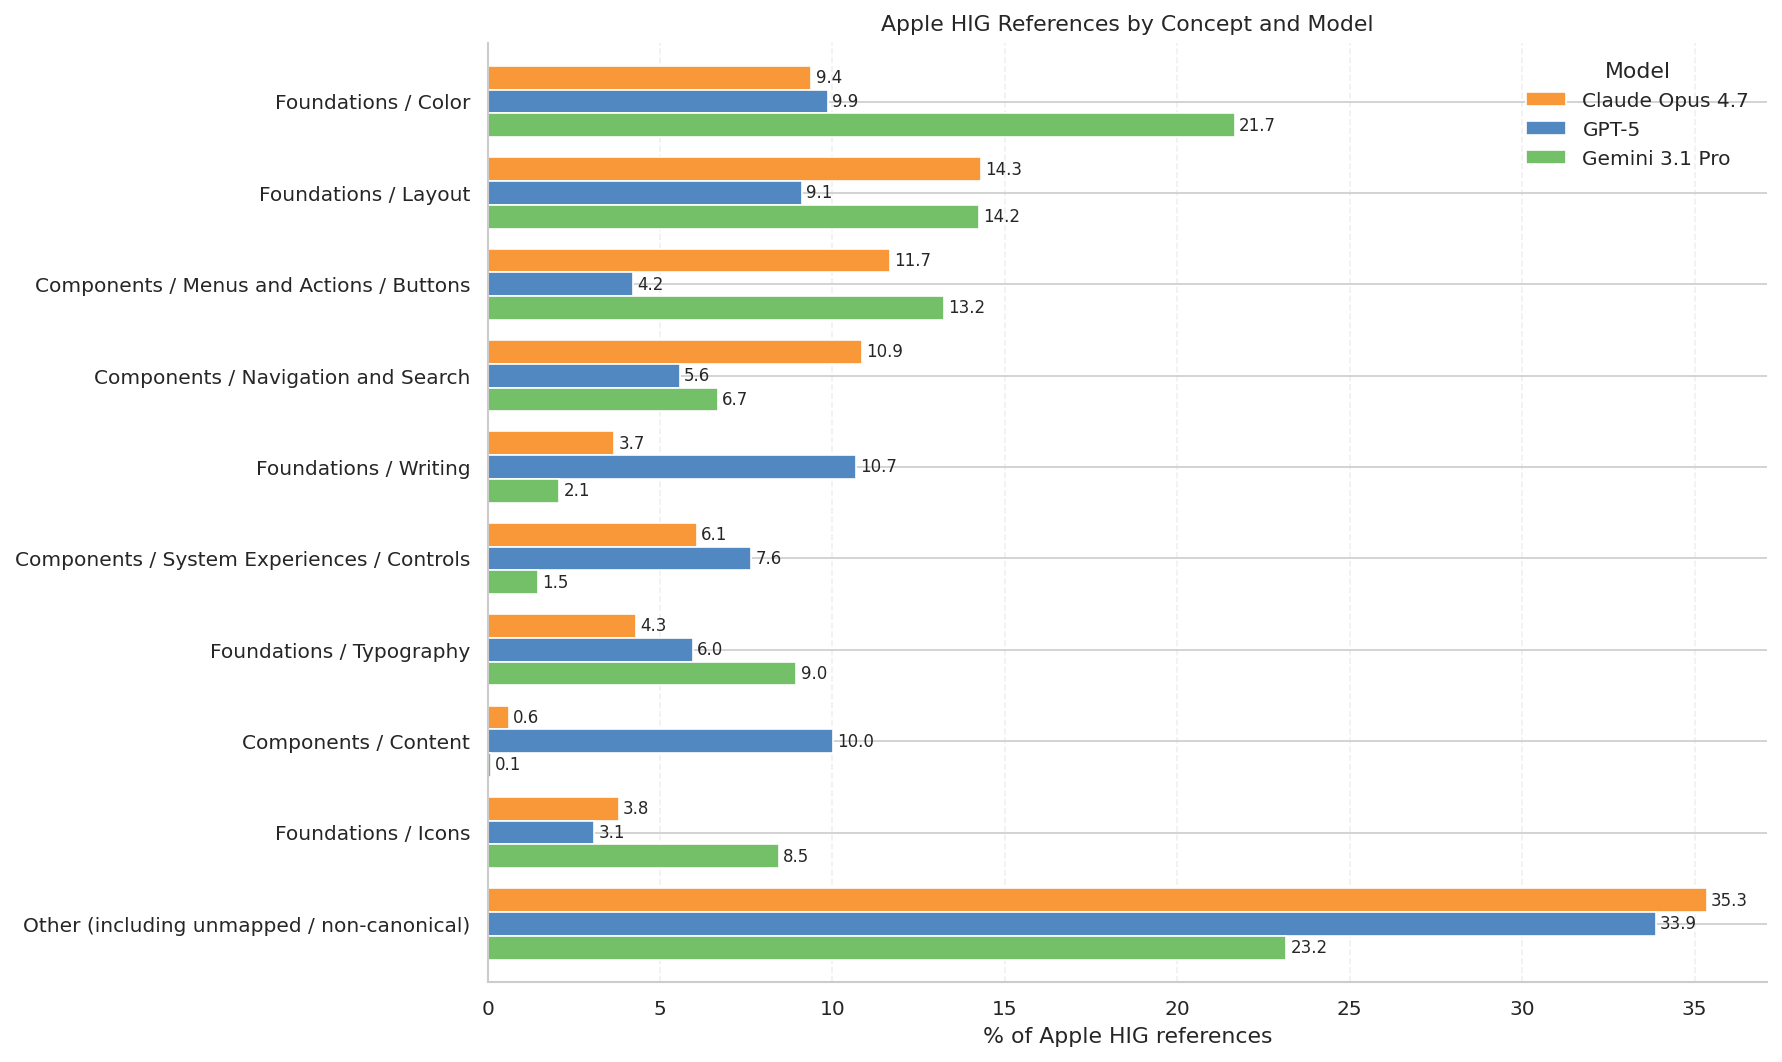

In [14]:
APPLE_TOP_K = 9
APPLE_OTHER_LABEL = "Other (including unmapped / non-canonical)"


def concept_text(value):
    return None if pd.isna(value) else (clean_text(value) or None)


apple_df = parsed_long_df.loc[parsed_long_df["source"].eq("Apple HIG")].copy()
apple_df["apple_concept"] = [
    " / ".join(part for part in (concept_text(category), concept_text(subcategory)) if part) or None
    for category, subcategory in zip(apple_df["category"], apple_df["subcategory"])
]

apple_is_mapped = apple_df["category"].apply(lambda value: normalize_key(value) in APPLE_TOP_LOOKUP)
apple_top_concepts = (
    apple_df.loc[apple_is_mapped, "apple_concept"].value_counts().head(APPLE_TOP_K).index.tolist()
)
apple_df["apple_plot_concept"] = apple_df["apple_concept"].where(
    apple_is_mapped & apple_df["apple_concept"].isin(apple_top_concepts),
    APPLE_OTHER_LABEL,
)

apple_plot_df = reference_percentage_matrix(
    apple_df, "apple_plot_concept", [*apple_top_concepts, APPLE_OTHER_LABEL]
)
display(apple_plot_df.round(2))
plot_reference_percentages(
    apple_plot_df,
    "Apple HIG References by Concept and Model",
    "% of Apple HIG references",
    "guideline_apple_hig.png",
    figsize=(12, 7.2),
)


#### 5.3.3 CrowdCrit Category Distribution

CrowdCrit's noisier free-text labels are merged into broader focus groups using the documented keyword rules above. The figure includes every grouped reference, orders the substantive focus groups by their pooled frequency across all three models, and places `Other / specific critique labels` last. Each row contains one bar per model; percentages are calculated within each model's CrowdCrit references and sum to 100% before rounding.


model_name,Claude Opus 4.7,GPT-5,Gemini 3.1 Pro
crowdcrit_focus,,,
"Color, Contrast & Legibility",12.08,34.23,32.01
Visual Hierarchy & Emphasis,22.54,26.76,7.68
"Labeling, Content & Information Clarity",20.92,8.45,0.52
Typography & Text,10.98,5.97,13.36
"Layout, Spacing & Alignment",10.14,5.87,12.59
Affordance & Usability,7.74,4.33,6.72
Consistency & Standards,3.43,1.83,6.57
Gestalt: Grouping & Proximity,3.32,2.87,4.95
Clutter & Simplicity,2.63,3.77,2.96


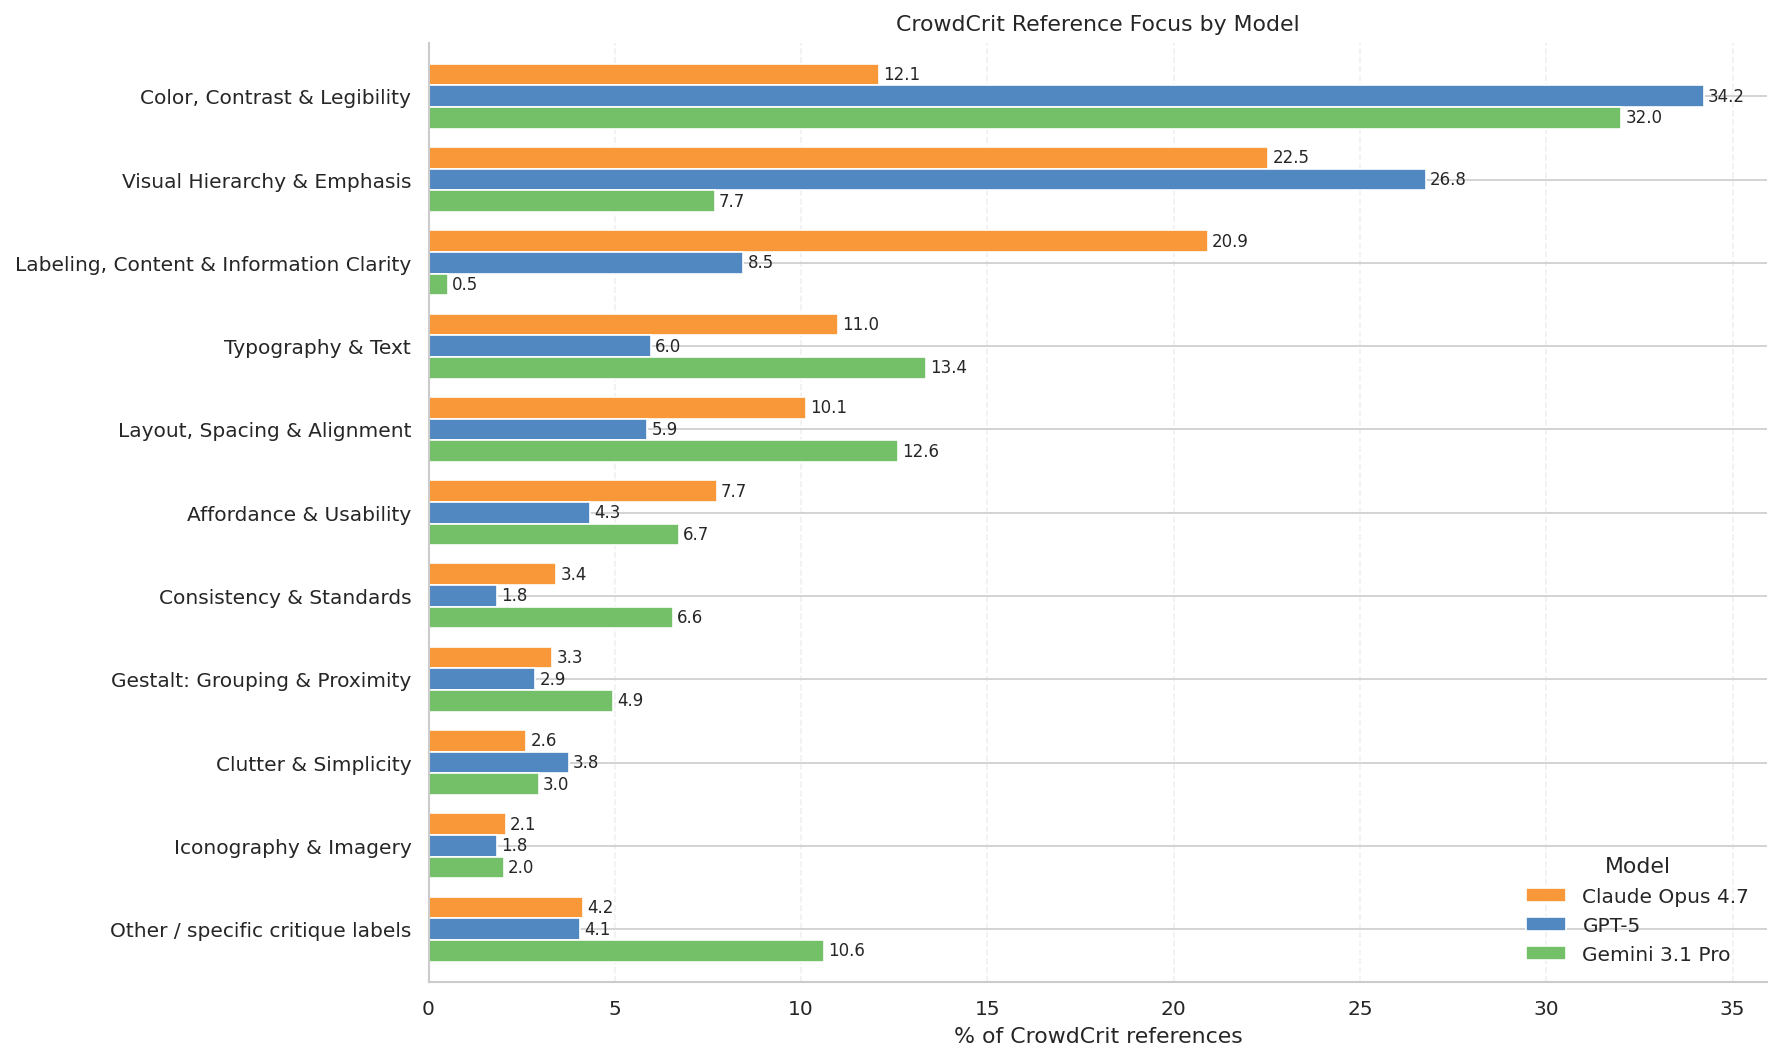

In [15]:
CROWDCRIT_OTHER_LABEL = "Other / specific critique labels"
CROWDCRIT_FOCUS_PATTERNS = {
    "Color, Contrast & Legibility": r"contrast|color|legib",
    "Visual Hierarchy & Emphasis": r"hierarch|emphasis|weight",
    "Typography & Text": r"typograph|text|readab",
    "Layout, Spacing & Alignment": r"layout|space|align|proportion|size",
    "Labeling, Content & Information Clarity": r"label|content|inform|clarity",
    "Gestalt: Grouping & Proximity": r"group|proximit|gestalt|unity|organi|differentiat",
    "Affordance & Usability": r"afford|usab|button|ui element|principle",
    "Iconography & Imagery": r"icon|imag",
    "Consistency & Standards": r"consisten|style|aesthetic|visual design",
    "Clutter & Simplicity": r"clutter|noise|simplic|redund",
}


def crowdcrit_focus(value):
    key = normalize_key(value)
    return next(
        (focus for focus, pattern in CROWDCRIT_FOCUS_PATTERNS.items() if re.search(pattern, key)),
        CROWDCRIT_OTHER_LABEL,
    )


crowdcrit_df = parsed_long_df.loc[parsed_long_df["source"].eq("CrowdCrit")].copy()
crowdcrit_df["crowdcrit_focus"] = crowdcrit_df["category"].apply(crowdcrit_focus)

crowdcrit_focus_order = (
    crowdcrit_df.loc[crowdcrit_df["crowdcrit_focus"].ne(CROWDCRIT_OTHER_LABEL), "crowdcrit_focus"]
    .value_counts()
    .index
    .tolist()
)
crowdcrit_plot_df = reference_percentage_matrix(
    crowdcrit_df, "crowdcrit_focus", [*crowdcrit_focus_order, CROWDCRIT_OTHER_LABEL]
)
display(crowdcrit_plot_df.round(2))
plot_reference_percentages(
    crowdcrit_plot_df,
    "CrowdCrit Reference Focus by Model",
    "% of CrowdCrit references",
    "guideline_crowdcrit.png",
    figsize=(12, 7.2),
)
